# `find_trapped_clusters`
Given an invasion sequence map and a set of outlets, returns a boolean mask of voxels of the displaced phase that are cut off from the outlets at some point during the invasion.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import porespy as ps

ps.visualization.set_mpl_style()

The arguments and their defaults are:

In [2]:
import inspect

inspect.signature(ps.filters.find_trapped_clusters)

<Signature (im: Union[collections.abc.Buffer, numpy._typing._array_like._SupportsArray[numpy.dtype[Any]], numpy._typing._nested_sequence._NestedSequence[numpy._typing._array_like._SupportsArray[numpy.dtype[Any]]], complex, bytes, str, numpy._typing._nested_sequence._NestedSequence[complex | bytes | str]], seq: Union[collections.abc.Buffer, numpy._typing._array_like._SupportsArray[numpy.dtype[Any]], numpy._typing._nested_sequence._NestedSequence[numpy._typing._array_like._SupportsArray[numpy.dtype[Any]]], complex, bytes, str, numpy._typing._nested_sequence._NestedSequence[complex | bytes | str]], outlets: Union[collections.abc.Buffer, numpy._typing._array_like._SupportsArray[numpy.dtype[Any]], numpy._typing._nested_sequence._NestedSequence[numpy._typing._array_like._SupportsArray[numpy.dtype[Any]]], complex, bytes, str, numpy._typing._nested_sequence._NestedSequence[complex | bytes | str]], min_size: int = 0, conn: Literal['min', 'max'] = 'min', method: Literal['queue', 'labels'] = 'lab

## `im`, `seq`, `outlets`
`im` is the boolean void mask, `seq` is an invasion-sequence map (e.g. the `im_seq` returned by `drainage` or `imbibition`), and `outlets` is a boolean mask of the cells through which the displaced phase can leave.

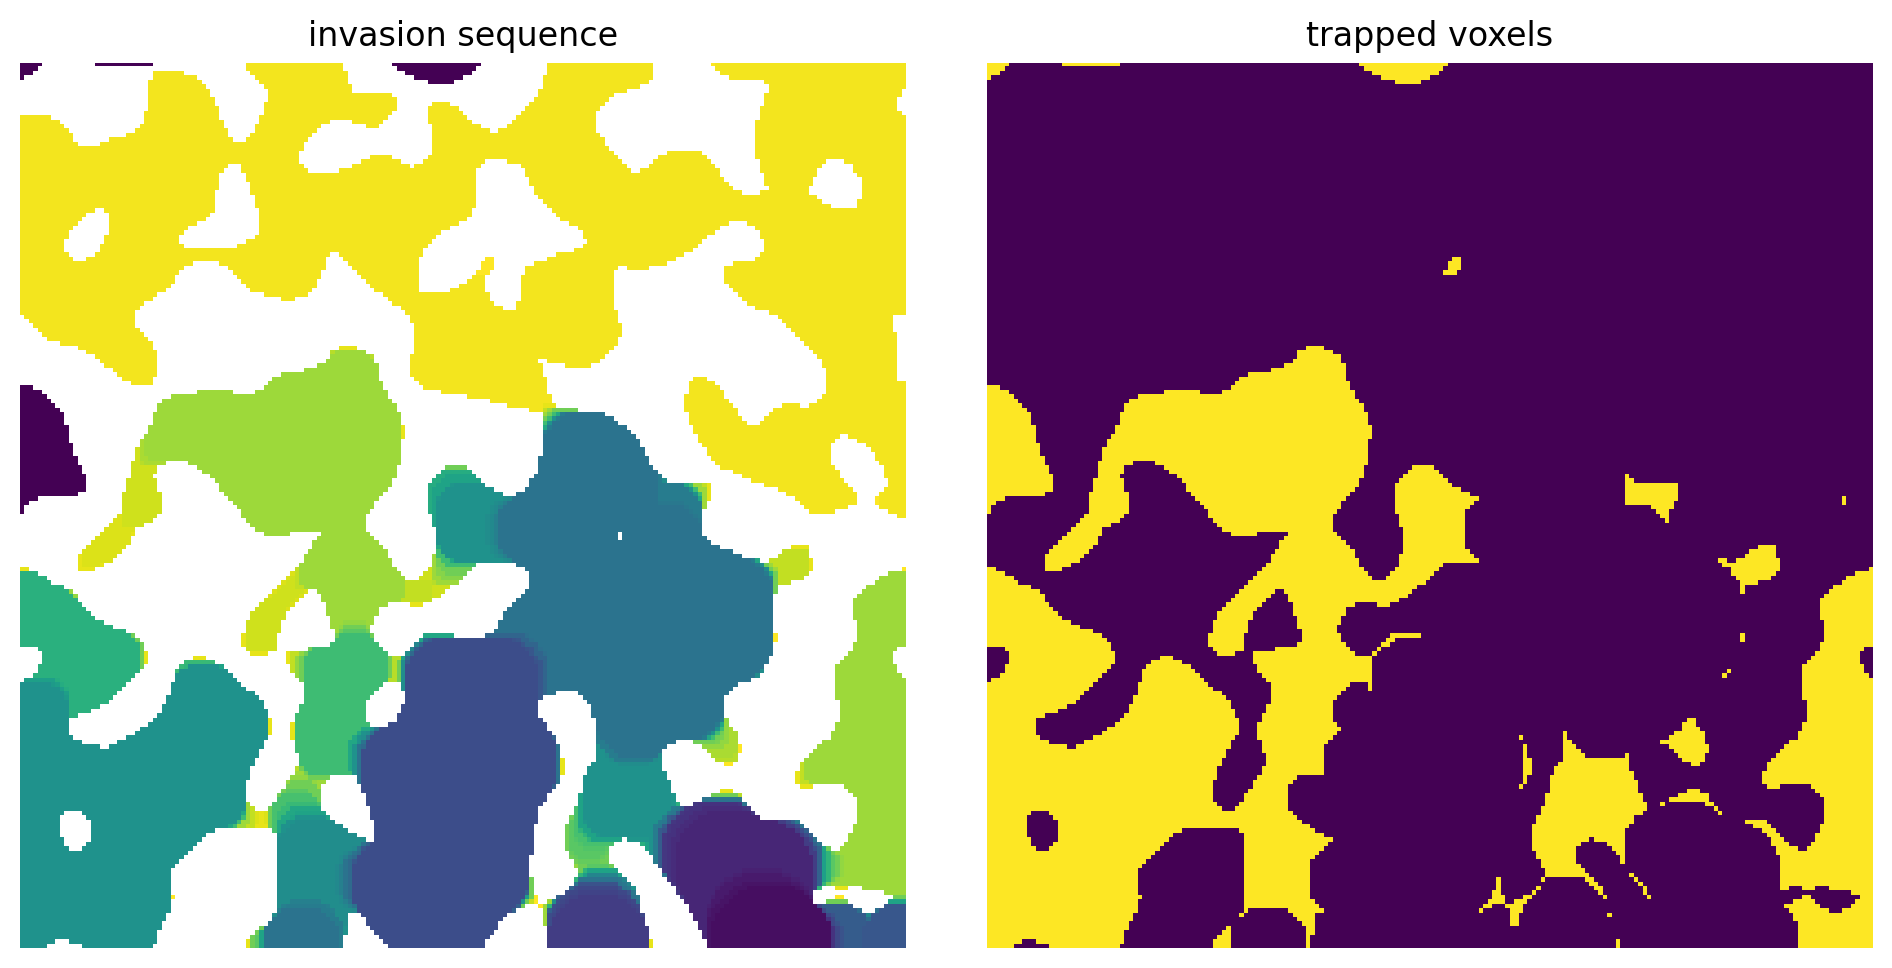

In [3]:
np.random.seed(0)
im = ps.generators.blobs(shape=[200, 200], porosity=0.65, seed=2)
im = ps.filters.fill_closed_pores(im)
inlets = ps.generators.faces(im.shape, inlet=0)
outlets = ps.generators.faces(im.shape, outlet=0)
pc = ps.filters.capillary_transform(
    im=im, sigma=0.072, theta=180, voxel_size=1e-5)
drn = ps.simulations.drainage(im=im, pc=pc, inlets=inlets)

trapped = ps.filters.find_trapped_clusters(
    im=im, seq=drn.im_seq, outlets=outlets)

fig, ax = plt.subplots(1, 2, figsize=[10, 5])
ax[0].imshow(drn.im_seq / im, origin='lower', interpolation='none')
ax[0].set_title('invasion sequence')
ax[0].axis(False)
ax[1].imshow(trapped, origin='lower', interpolation='none')
ax[1].set_title('trapped voxels')
ax[1].axis(False);

## `method`
Two algorithms are available. `'labels'` (default) uses `scipy.ndimage.label` at each sequence step and is faster on the bulk-invasion sequences produced by `drainage`. `'queue'` walks the invasion in reverse using a priority queue and is faster on `ibip`/`qbip`-style step-by-step sequences. The two return the same answer.

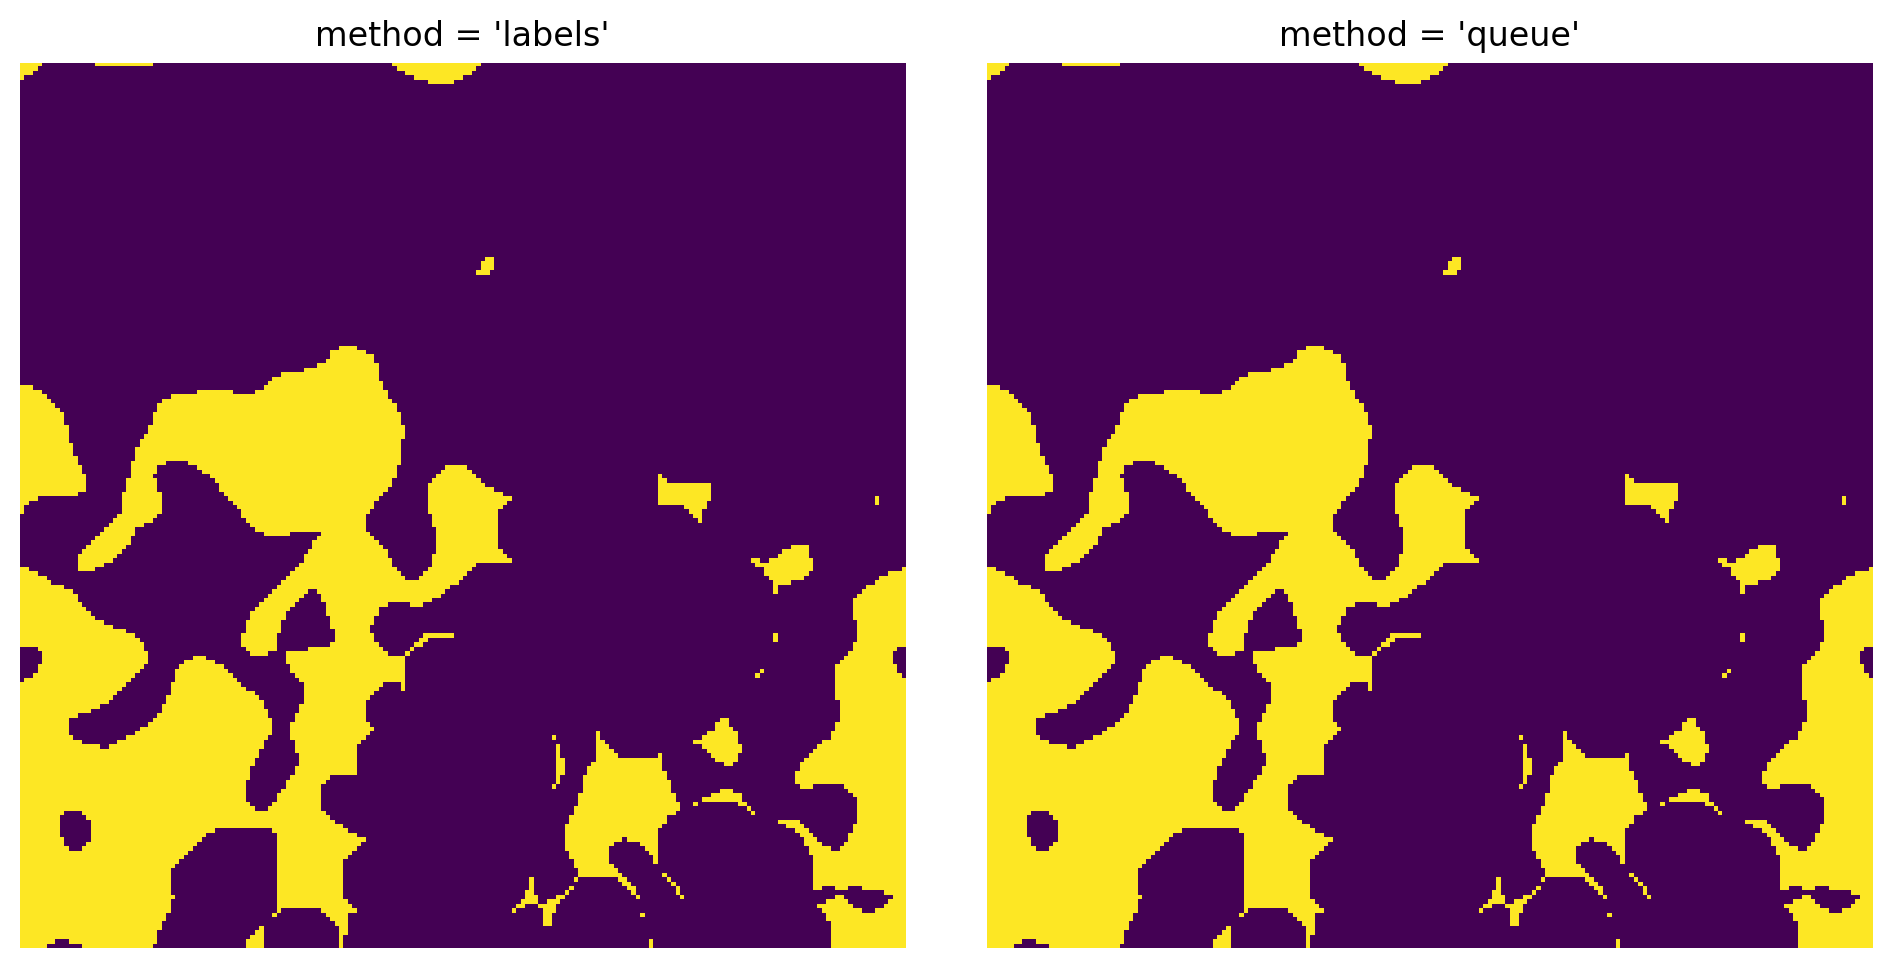

In [4]:
trap_labels = ps.filters.find_trapped_clusters(
    im=im, seq=drn.im_seq, outlets=outlets, method='labels')
trap_queue = ps.filters.find_trapped_clusters(
    im=im, seq=drn.im_seq, outlets=outlets, method='queue')

fig, ax = plt.subplots(1, 2, figsize=[10, 5])
ax[0].imshow(trap_labels, origin='lower', interpolation='none')
ax[0].set_title("method = 'labels'")
ax[0].axis(False)
ax[1].imshow(trap_queue, origin='lower', interpolation='none')
ax[1].set_title("method = 'queue'")
ax[1].axis(False);

## `min_size`
Trapped clusters smaller than this many voxels are not flagged. Useful for stripping pixel-scale digital artefacts that pile up against solid walls.

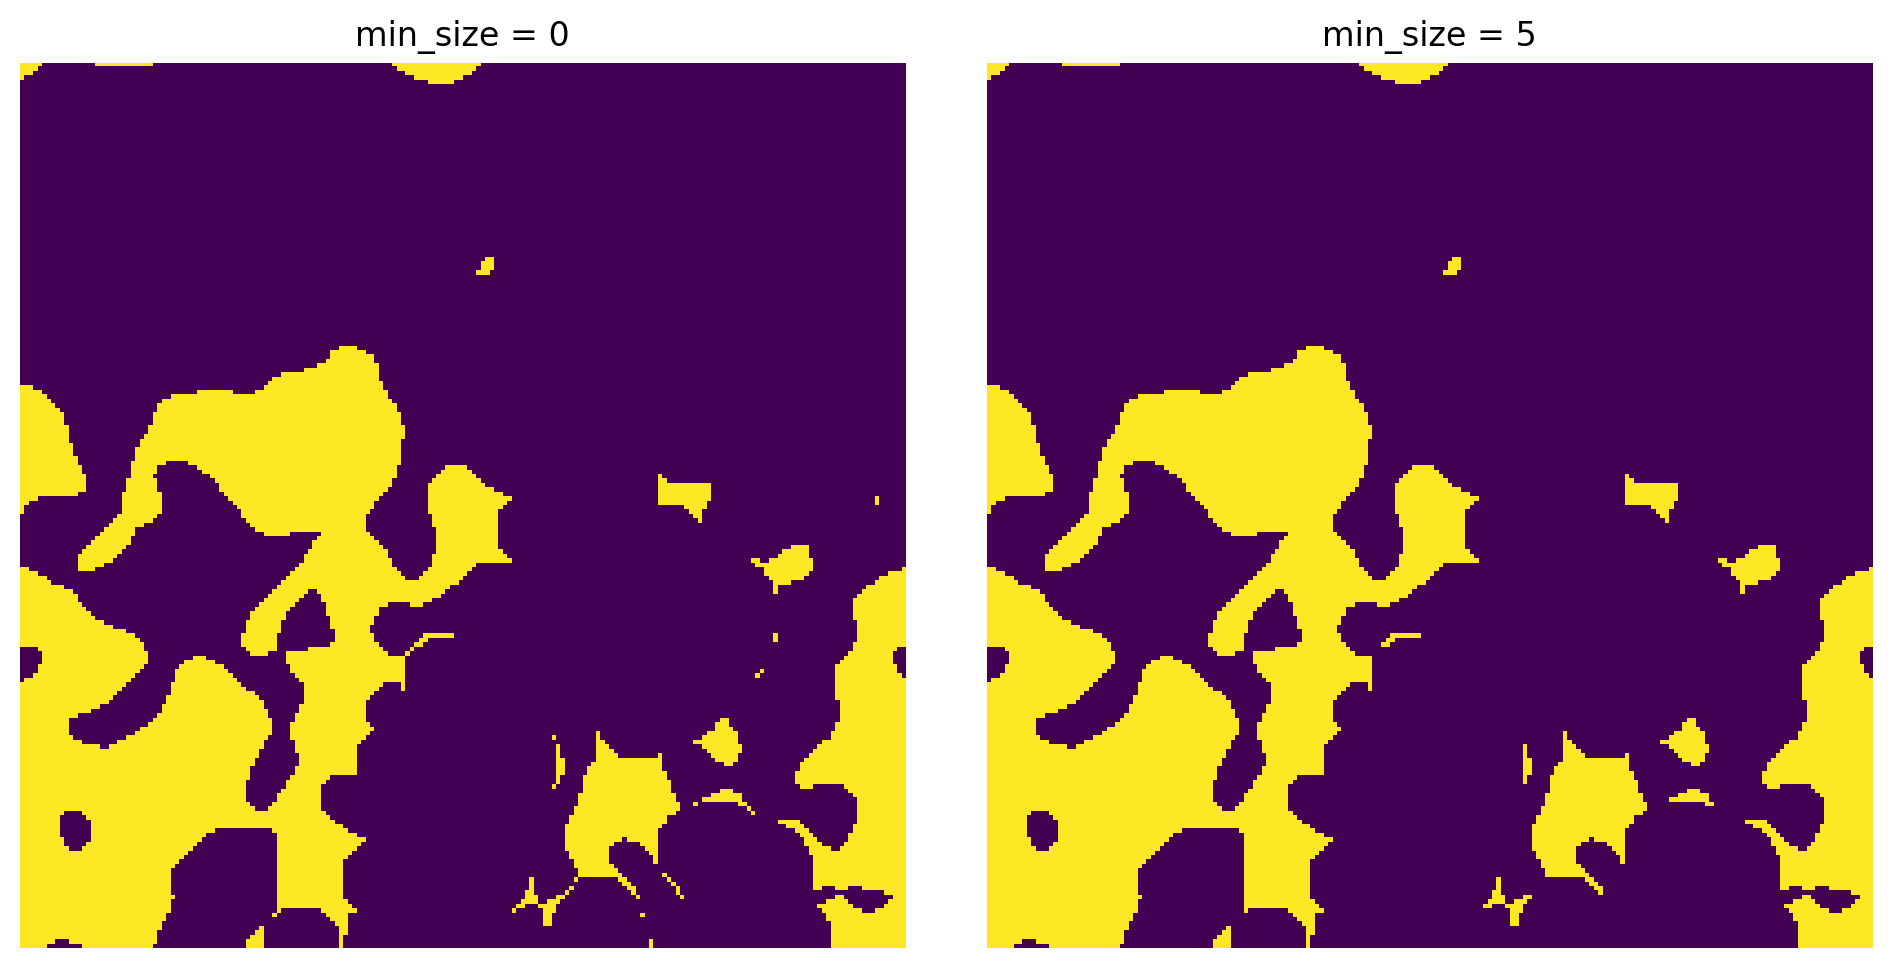

In [5]:
trap0 = ps.filters.find_trapped_clusters(
    im=im, seq=drn.im_seq, outlets=outlets, min_size=0)
trap5 = ps.filters.find_trapped_clusters(
    im=im, seq=drn.im_seq, outlets=outlets, min_size=5)

fig, ax = plt.subplots(1, 2, figsize=[10, 5])
ax[0].imshow(trap0, origin='lower', interpolation='none')
ax[0].set_title('min_size = 0')
ax[0].axis(False)
ax[1].imshow(trap5, origin='lower', interpolation='none')
ax[1].set_title('min_size = 5')
ax[1].axis(False);

## `conn`
Controls voxel connectivity used when grouping trapped voxels. `'min'` (default) requires shared faces; `'max'` accepts edges and corners.

In [6]:
trap_min = ps.filters.find_trapped_clusters(
    im=im, seq=drn.im_seq, outlets=outlets, conn='min')
trap_max = ps.filters.find_trapped_clusters(
    im=im, seq=drn.im_seq, outlets=outlets, conn='max')

print("conn = 'min':", int(trap_min.sum()), 'voxels')
print("conn = 'max':", int(trap_max.sum()), 'voxels')

conn = 'min': 9238 voxels
conn = 'max': 9224 voxels
